In [63]:
# ================================================================
# PORTFOLIO OPTIMIZATION — TQC vs SAC ABLATION STUDY
# Thesis Extension: Mengganti / Membandingkan SAC dengan TQC
#
# Perubahan utama dari versi SAC:
#   1. Tambah konfigurasi 'E2_TQC_NoMarket' dan 'E2_TQC_WithMarket'
#      menggunakan TQC (Truncated Quantile Critics) dari sb3-contrib.
#   2. TQC secara native mendukung distributional RL → CVaR bisa
#      dioptimasi secara langsung lewat parameter top_quantiles_to_drop_per_net.
#   3. Semua helper, environment, dan backtest engine TIDAK diubah
#      sehingga hasil tetap apple-to-apple dengan eksperimen SAC sebelumnya.
#   4. Ditambahkan fungsi compare_sac_vs_tqc() untuk ringkasan cepat.
#
# Instalasi tambahan yang dibutuhkan:
#   pip install sb3-contrib
# ================================================================


## 0. Install check

In [64]:
# 0. Install check


In [65]:
try:
    from sb3_contrib import TQC
    print("sb3-contrib OK — TQC tersedia.")
except ImportError:
    raise ImportError(
        "sb3-contrib belum terinstall.\n"
        "Jalankan: pip install sb3-contrib\n"
        "lalu restart kernel dan run ulang file ini."
    )


sb3-contrib OK — TQC tersedia.


## 1. Import & Global Settings

In [66]:
# 1. Import & Global Settings
#    (identik dengan file asli, cukup copy-paste bagian GLOBAL SETTINGS)


## ── Global hyperparameters ──────────────────────────────────────

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
from scipy import stats
from scipy.optimize import minimize
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from networkx.algorithms import community

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('tqc_results', exist_ok=True)

# ── Global hyperparameters ──────────────────────────────────────
SEEDS          = [42, 123, 77]
TRAIN_STEPS    = 100
GAMMA_CENTER   = 0
SET_WINDOW     = 30
SET_REBALANCE  = 7
REWARD_WINDOW  = 20
CVAR_LEVEL     = 0.95
STAT_ALPHA     = 0.05

# ── Konfigurasi Ablation (SAC + TQC side-by-side) ──────────────
#
# Penjelasan parameter TQC:
#   top_quantiles_to_drop_per_net:
#     Jumlah quantile teratas yang di-drop saat menghitung target.
#     Makin besar → policy lebih risk-averse (mengoptimasi CVaR lebih kuat).
#     Default SB3 = 2. Untuk CVaR-focused: coba nilai 4–6.
#     Trade-off: nilai terlalu besar → underestimate Q-value → training lambat.
#
#   n_quantiles:
#     Jumlah quantile yang dimodelkan per critic.
#     Default = 25. Nilai lebih tinggi → estimasi distribusi lebih halus
#     tapi lebih berat secara komputasi.
#
ABLATION_CONFIGS = {
    # ── Baseline (dari file asli, tetap disertakan untuk perbandingan) ──
    'Comp_Static_Gamma0': {
        'use_network': True, 'use_market': False,
        'extra_features': [], 'static_gamma': 0.0,
        'algo': 'static',
        'feature_desc': 'Static Gamma 0.0 (Deterministic)'
    },
    'Comp_Static_Gamma1': {
        'use_network': True, 'use_market': False,
        'extra_features': [], 'static_gamma': 1.0,
        'algo': 'static',
        'feature_desc': 'Static Gamma 1.0 (Deterministic)'
    },
    'Comp_Static_Gamma2': {
        'use_network': True, 'use_market': False,
        'extra_features': [], 'static_gamma': 2.0,
        'algo': 'static',
        'feature_desc': 'Static Gamma 2.0 (Deterministic)'
    },
    'Classic-MV': {
        'use_network': False, 'use_market': False,
        'extra_features': [], 'algo': 'classic',
        'feature_desc': 'Standard Baseline (Deterministic)'
    },

    # ── SAC (model asli, dari file sebelumnya) ──
    'E2_SAC_NoMarket': {
        'use_network': True, 'use_market': False,
        'extra_features': [], 'algo': 'sac',
        'feature_desc': 'Network(5)'
    },
    'E2_SAC_WithMarket': {
        'use_network': True, 'use_market': True,
        'extra_features': [], 'algo': 'sac',
        'feature_desc': 'Network(5) + Market(4)'
    },

    # ── TQC — drop-in pengganti SAC ──
    'E2_TQC_NoMarket': {
        'use_network': True, 'use_market': False,
        'extra_features': [], 'algo': 'tqc',
        'tqc_top_quantiles_to_drop': 2,
        'tqc_n_quantiles': 25,
        'feature_desc': 'Network(5) [TQC]'
    },
    'E2_TQC_WithMarket': {
        'use_network': True, 'use_market': True,
        'extra_features': [], 'algo': 'tqc',
        'tqc_top_quantiles_to_drop': 2,
        'tqc_n_quantiles': 25,
        'feature_desc': 'Network(5) + Market(4) [TQC]'
    },

    # ── TQC — versi lebih risk-averse (CVaR-optimized) ──
    'E2_TQC_CVaR_Focused': {
        'use_network': True, 'use_market': True,
        'extra_features': [], 'algo': 'tqc',
        'tqc_top_quantiles_to_drop': 5,
        'tqc_n_quantiles': 25,
        'feature_desc': 'Network(5) + Market(4) [TQC-RiskAverse]'
    },
}

print("Libraries loaded.")
print(f"Ablation configs: {list(ABLATION_CONFIGS.keys())}")
print(f"SEEDS={SEEDS} | TRAIN_STEPS={TRAIN_STEPS} | CVaR level={CVAR_LEVEL*100:.0f}%")


Libraries loaded.
Ablation configs: ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2', 'Classic-MV', 'E2_SAC_NoMarket', 'E2_SAC_WithMarket', 'E2_TQC_NoMarket', 'E2_TQC_WithMarket', 'E2_TQC_CVaR_Focused']
SEEDS=[42, 123, 77] | TRAIN_STEPS=100 | CVaR level=95%


## 2. Data Loading

In [68]:
# 2. Data Loading


In [69]:
FILE_DATA = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(FILE_DATA)

print(f"\nAssets ({len(assets)}): {assets}")
print(f"Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)")
print(f"Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)")


USDT removed from assets.

Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## 3. Portfolio Optimization Helpers

In [70]:
# 3. Portfolio Optimization Helpers
#    (copy dari file asli — tidak ada perubahan)


In [71]:

def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


def _build_mst_centrality(N, corr_f):
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu     = returns_window.mean().values
    sigma  = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    _, cent_vec = _build_mst_centrality(N, corr_f)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


def compute_classic_mv_weights(returns_window):
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


## 4. Metric Helpers

In [72]:
# 4. Metric Helpers


In [73]:

def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    return (cumulative - peak) / peak, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    if total <= 0: return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    if ann_vol <= 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / ann_vol


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0: return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    if downside_dev <= 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / downside_dev


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    if max_dd == 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / abs(max_dd)


def calculate_cvar(ret_series, confidence=0.95):
    arr = np.array(ret_series)
    var = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    if len(tail_losses) == 0: return 0.0
    return float(-np.mean(tail_losses))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    downside = arr[arr < 0]
    down_std = np.std(downside) * np.sqrt(periods_per_year) if len(downside) > 0 else 0.0
    return {
        'Sharpe Ratio'   : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'  : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'   : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'     : calculate_cvar(arr, cvar_level),
        'Total Return'   : total_ret,
        'Ann. Return'    : ann_ret,
        'Ann. Volatility': ann_vol,
        'Downside Std'   : down_std,
        'Max Drawdown'   : max_dd,
    }


## 5. Feature Engineering

In [74]:
# 5. Feature Engineering
#    (copy dari file asli — tidak ada perubahan)


In [75]:

def compute_network_features(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    upper_idx = np.triu_indices(N, k=1)
    density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    avg_clustering = nx.average_clustering(mst)
    avg_path_len = nx.average_shortest_path_length(mst)
    comm = list(community.greedy_modularity_communities(mst))
    mod_score = community.modularity(mst, comm)
    spectral_gap = nx.algebraic_connectivity(mst)
    bet_cent = nx.betweenness_centrality(mst)
    bet_mean = np.mean(list(bet_cent.values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density,
        avg_clustering    * 10,
        avg_path_len      * 0.1,
        mod_score,
        spectral_gap,
        bet_mean          * 10,
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    arr = returns_window.values
    T, N = arr.shape
    window_5  = max(1, min(5, T))
    window_20 = max(1, min(20, T))
    rolling_vol_5  = arr[-window_5:].std(axis=0).mean()
    rolling_vol_20 = arr[-window_20:].std(axis=0).mean()
    vol_ratio      = rolling_vol_5 / (rolling_vol_20 + 1e-8)
    mom_5d    = arr[-window_5:].mean(axis=0).mean()
    mom_20d   = arr[-window_20:].mean(axis=0).mean()
    mom_cross = mom_5d - mom_20d
    port_val_norm = port_val - 1.0
    ma_20       = arr[-window_20:].mean(axis=0)
    ret_5d_per  = arr[-window_5:].mean(axis=0)
    pct_uptrend = float(np.mean(ret_5d_per > ma_20))
    avg_ret_5d     = arr[-window_5:].mean()
    ret_dispersion = arr[-window_5:].mean(axis=0).std()
    return np.array([
        rolling_vol_5  * 100,
        rolling_vol_20 * 100,
        vol_ratio,
        mom_5d    * 100,
        mom_20d   * 100,
        mom_cross * 100,
        port_val_norm,
        pct_uptrend,
        avg_ret_5d  * 100,
        ret_dispersion * 100,
    ], dtype=np.float32)


def compute_extra_features(returns_window, corr_f, extra_list):
    extra = []
    if 'downside_vol' in extra_list:
        ret_flat = returns_window.values.flatten()
        downside = ret_flat[ret_flat < 0]
        dv = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
        extra.append(float(dv) * 10)
    if 'avg_corr' in extra_list:
        upper_tri = corr_f[np.triu_indices_from(corr_f, k=1)]
        extra.append(float(np.mean(np.abs(upper_tri))))
    return np.array(extra, dtype=np.float32)


## 6. Global Cache & Normalization

In [76]:
# 6. Global Cache & Normalization


In [77]:
print("\n=== Phase: Global Precompute Cache ===")
GLOBAL_CACHE = {}

print(f"Menghitung cache training: {len(ret_train) - SET_WINDOW} windows...")
for i in range(SET_WINDOW, len(ret_train)):
    win   = ret_train.iloc[i - SET_WINDOW: i]
    mu    = win.mean().values
    sigma = win.std().values
    nw_feat_full, corr_f, cent_vec = compute_network_features(win)
    T, N  = win.shape
    cov_f = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    GLOBAL_CACHE[i] = {
        'win': win, 'corr_f': corr_f, 'cent_vec': cent_vec,
        'cov_f': cov_f, 'mu': mu, 'sigma': sigma,
        'nw_feat_full': nw_feat_full,
    }

feat_matrix_train = np.stack([GLOBAL_CACHE[i]['nw_feat_full']
                               for i in sorted(GLOBAL_CACHE.keys())])
FEAT_MEAN = feat_matrix_train.mean(axis=0)
FEAT_STD  = feat_matrix_train.std(axis=0) + 1e-8

print(f"Menghitung cache testing: {len(ret_test) - SET_WINDOW} windows...")
for i in range(SET_WINDOW, len(ret_test)):
    win   = ret_test.iloc[i - SET_WINDOW: i]
    mu    = win.mean().values
    sigma = win.std().values
    nw_feat_full, corr_f, cent_vec = compute_network_features(win)
    T, N  = win.shape
    cov_f = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    global_idx = len(ret_train) + i
    GLOBAL_CACHE[global_idx] = {
        'win': win, 'corr_f': corr_f, 'cent_vec': cent_vec,
        'cov_f': cov_f, 'mu': mu, 'sigma': sigma,
        'nw_feat_full': nw_feat_full,
    }

print(f"Global cache selesai: {len(GLOBAL_CACHE)} windows.")


def normalize_features(nw_feat):
    return (nw_feat - FEAT_MEAN) / FEAT_STD


def get_obs_dim(config):
    dim = 0
    if config['use_network']:
        dim += (9 if 'drop_nw_idx' in config else 10)
    if config['use_market']:
        dim += 10
    dim += len(config.get('extra_features', []))
    return max(dim, 1)


def build_observation(returns_window, config, port_val=0.0,
                       nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None or corr_f is None:
        nw_feat_raw, corr_f, cent_vec = compute_network_features(returns_window)
    nw_feat = normalize_features(nw_feat_raw)
    if 'drop_nw_idx' in config:
        nw_feat = np.delete(nw_feat, config['drop_nw_idx'])
    mkt_feat   = compute_market_features(returns_window, port_val)
    extra_feat = compute_extra_features(returns_window, corr_f,
                                        config.get('extra_features', []))
    parts = []
    if config['use_network']: parts.append(nw_feat)
    if config['use_market']:  parts.append(mkt_feat)
    if len(extra_feat) > 0:   parts.append(extra_feat)
    obs = np.concatenate(parts) if parts else np.array([0.0], dtype=np.float32)
    return np.nan_to_num(obs), corr_f, None


def build_caches_from_global(config, global_cache):
    obs_cache, opt_cache = {}, {}
    for i, data in global_cache.items():
        obs, _, _ = build_observation(
            data['win'], config, port_val=0.0,
            nw_feat_raw=data['nw_feat_full'], corr_f=data['corr_f']
        )
        obs_cache[i] = obs
        opt_cache[i] = (data['cov_f'], data['cent_vec'], data['mu'])
    return obs_cache, opt_cache


print("Feature engineering & cache utilities siap.")
print("Observation dimensions per config:")
for name, cfg in ABLATION_CONFIGS.items():
    print(f"  {name}: {get_obs_dim(cfg)} features | algo={cfg.get('algo','static')}")



=== Phase: Global Precompute Cache ===
Menghitung cache training: 504 windows...
Menghitung cache testing: 199 windows...
Global cache selesai: 703 windows.
Feature engineering & cache utilities siap.
Observation dimensions per config:
  Comp_Static_Gamma0: 10 features | algo=static
  Comp_Static_Gamma1: 10 features | algo=static
  Comp_Static_Gamma2: 10 features | algo=static
  Classic-MV: 1 features | algo=classic
  E2_SAC_NoMarket: 10 features | algo=sac
  E2_SAC_WithMarket: 20 features | algo=sac
  E2_TQC_NoMarket: 10 features | algo=tqc
  E2_TQC_WithMarket: 20 features | algo=tqc
  E2_TQC_CVaR_Focused: 20 features | algo=tqc


## 7. RL Environment

In [78]:
# 7. RL Environment
#    (identik dengan file asli)


In [79]:

class AblationPortfolioEnv(gym.Env):
    def __init__(self, returns_data, obs_cache, opt_cache,
                 config, window_size=30, gamma_center=1.0, data_start_offset=0):
        super().__init__()
        self.data              = returns_data
        self.obs_cache         = obs_cache
        self.opt_cache         = opt_cache
        self.config            = config
        self.window_size       = window_size
        self.gamma_center      = gamma_center
        self.data_start_offset = data_start_offset
        self.current_step      = window_size
        self.port_val          = 1.0
        self.peak_val          = 1.0
        self._returns_buffer   = []
        self._reward_window    = REWARD_WINDOW
        self._rew_mean         = 0.0
        self._rew_M2           = 0.0
        self._rew_count        = 0

        obs_dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)

    def _get_obs(self):
        global_idx = self.data_start_offset + self.current_step
        obs = self.obs_cache[global_idx].copy()
        if self.config['use_market']:
            nw_offset = (9 if 'drop_nw_idx' in self.config else 10) if self.config['use_network'] else 0
            port_val_idx = nw_offset + 6
            if port_val_idx < len(obs):
                obs[port_val_idx] = self.port_val - 1.0
        return obs

    def _normalize_reward(self, r):
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return float(np.clip(r / std, -10.0, 10.0))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = self.window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._returns_buffer = []
        self._rew_mean       = 0.0
        self._rew_M2         = 0.0
        self._rew_count      = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > self._reward_window:
            self._returns_buffer.pop(0)

        arr = np.array(self._returns_buffer)
        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            drawdown, _ = _compute_drawdown(arr)
            max_dd      = drawdown.min()
            ann_ret     = calculate_annualized_return(arr)
            if np.isnan(ann_ret):
                ann_ret = arr.mean() * 252
            denominator = abs(max_dd) if abs(max_dd) > 1e-8 else 1e-8
            calmar      = ann_ret / denominator
            raw_reward  = float(np.clip(calmar, -10.0, 10.0))

        reward = self._normalize_reward(raw_reward)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, reward, done, False, {}


print("AblationPortfolioEnv defined.")


AblationPortfolioEnv defined.


## 8. Learning Curve Callback

In [80]:
# 8. Learning Curve Callback


In [81]:

class LearningCurveCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards    = []
        self._current_ep_reward = 0.0

    def _on_step(self):
        reward = self.locals.get('rewards', [0])[0]
        done   = self.locals.get('dones', [False])[0]
        self._current_ep_reward += reward
        if done:
            self.episode_rewards.append(self._current_ep_reward)
            self._current_ep_reward = 0.0
        return True

    def get_smoothed(self, window=20):
        r = np.array(self.episode_rewards)
        return r if len(r) < window else np.convolve(r, np.ones(window) / window, mode='valid')


## 9. Model Factory

In [82]:
# 9. Model Factory
#    INI bagian utama yang membedakan file ini dari versi asli.
#    Fungsi build_model() memilih SAC atau TQC berdasarkan config['algo'].


## Shared hyperparameters (berlaku untuk SAC dan TQC)

In [83]:

# Shared hyperparameters (berlaku untuk SAC dan TQC)
SHARED_KWARGS = {
    'policy'         : 'MlpPolicy',
    'learning_rate'  : 3e-4,
    'buffer_size'    : 50000,
    'batch_size'     : 256,
    'ent_coef'       : 'auto',
    'train_freq'     : 1,
    'gradient_steps' : 1,
    'learning_starts': 200,
    'tau'            : 0.005,
    'gamma'          : 0.99,
}


def build_model(env, config, seed):
    """
    Factory function: return SAC atau TQC instance sesuai config['algo'].

    TQC-specific args yang bisa dikontrol lewat config:
      tqc_top_quantiles_to_drop_per_net  → trade-off risk-aversion
      tqc_n_quantiles                    → resolusi distribusi Q
    """
    algo = config.get('algo', 'sac')

    if algo == 'sac':
        return SAC(env=env, seed=seed, verbose=0, **SHARED_KWARGS)

    elif algo == 'tqc':
        tqc_kwargs = dict(SHARED_KWARGS)
        # TQC-specific: kita pass sebagai policy_kwargs agar kompatibel dengan SB3
        top_q_drop = config.get('tqc_top_quantiles_to_drop', 2)
        n_q        = config.get('tqc_n_quantiles', 25)
        tqc_kwargs['top_quantiles_to_drop_per_net'] = top_q_drop
        tqc_kwargs['policy_kwargs'] = {'n_quantiles': n_q}
        return TQC(env=env, seed=seed, verbose=0, **tqc_kwargs)

    else:
        raise ValueError(f"Unknown algo: {algo}. Pilih 'sac' atau 'tqc'.")


## 10. Training Loop

In [84]:
# 10. Training Loop


In [85]:
learning_curves    = {}
trained_model_paths = {}

sep = '=' * 65
for exp_id, config in ABLATION_CONFIGS.items():
    print(f"\n{sep}")
    print(f"Experiment : {exp_id}")
    print(f"Algo       : {config.get('algo', 'static')}")
    print(f"Obs dim    : {get_obs_dim(config)}")

    obs_cache, opt_cache = build_caches_from_global(config, GLOBAL_CACHE)

    for seed in SEEDS:
        # Static/Classic benchmark tidak perlu training
        if config.get('algo') in ['static', 'classic'] or config.get('static_gamma') is not None:
            if seed == SEEDS[0]:
                print(f"  Static benchmark — tidak perlu training.")
            trained_model_paths[(exp_id, seed)] = 'static'
            continue

        print(f"  Training seed={seed} | steps={TRAIN_STEPS} | algo={config['algo']}...")
        env = AblationPortfolioEnv(
            ret_train, obs_cache, opt_cache, config,
            window_size=SET_WINDOW, gamma_center=GAMMA_CENTER,
        )

        model       = build_model(env, config, seed)
        lc_callback = LearningCurveCallback()
        model.learn(total_timesteps=TRAIN_STEPS, callback=lc_callback, progress_bar=True)

        learning_curves[(exp_id, seed)] = lc_callback

        # Simpan model dengan prefix algo agar tidak bentrok
        model_name = f"{config['algo']}_{exp_id}_seed{seed}"
        model.save(model_name)
        trained_model_paths[(exp_id, seed)] = model_name
        print(f"    Saved: {model_name}.zip | Episodes: {len(lc_callback.episode_rewards)}")

print("\n=== Semua model selesai dilatih ===")



Experiment : Comp_Static_Gamma0
Algo       : static
Obs dim    : 10
  Static benchmark — tidak perlu training.

Experiment : Comp_Static_Gamma1
Algo       : static
Obs dim    : 10
  Static benchmark — tidak perlu training.

Experiment : Comp_Static_Gamma2
Algo       : static
Obs dim    : 10
  Static benchmark — tidak perlu training.

Experiment : Classic-MV
Algo       : classic
Obs dim    : 1
  Static benchmark — tidak perlu training.

Experiment : E2_SAC_NoMarket
Algo       : sac
Obs dim    : 10


Output()

  Training seed=42 | steps=100 | algo=sac...


Output()

    Saved: sac_E2_SAC_NoMarket_seed42.zip | Episodes: 0
  Training seed=123 | steps=100 | algo=sac...


...

Output()

    Saved: tqc_E2_TQC_CVaR_Focused_seed42.zip | Episodes: 0
  Training seed=123 | steps=100 | algo=tqc...


Output()

    Saved: tqc_E2_TQC_CVaR_Focused_seed123.zip | Episodes: 0
  Training seed=77 | steps=100 | algo=tqc...


    Saved: tqc_E2_TQC_CVaR_Focused_seed77.zip | Episodes: 0

=== Semua model selesai dilatih ===


## 11. Strategy & Backtest

In [86]:
# 11. Strategy & Backtest


In [87]:

class AblationStrategy:
    def __init__(self, name, model_path, config, gamma_center=1.0, global_cache=None):
        self.name         = name
        self.config       = config
        self.gamma_center = gamma_center
        self.global_cache = global_cache
        self.is_static    = (config.get('static_gamma') is not None
                             or config.get('algo') in ['static', 'classic'])

        if self.is_static:
            self.model      = None
            self.last_gamma = config.get('static_gamma', gamma_center)
        else:
            algo = config.get('algo', 'sac')
            if algo == 'sac':
                self.model = SAC.load(model_path)
            elif algo == 'tqc':
                self.model = TQC.load(model_path)
            else:
                raise ValueError(f"Unknown algo: {algo}")
            self.last_gamma = gamma_center

    def compute_weights(self, returns_window, port_val=1.0, step_idx=None):
        cached_data = None
        if self.global_cache is not None and step_idx in self.global_cache:
            cached_data = self.global_cache[step_idx]

        if self.config.get('algo') == 'classic':
            return compute_classic_mv_weights(returns_window)

        if self.is_static:
            self.last_gamma = self.config.get('static_gamma', self.gamma_center)
        else:
            if cached_data is not None:
                obs, _, _ = build_observation(
                    returns_window, self.config, port_val=port_val - 1.0,
                    nw_feat_raw=cached_data['nw_feat_full'],
                    corr_f=cached_data['corr_f']
                )
            else:
                obs, _, _ = build_observation(returns_window, self.config,
                                               port_val=port_val - 1.0)
            action, _ = self.model.predict(obs, deterministic=True)
            self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center

        if cached_data is not None:
            return fast_centrality_weights(
                cached_data['cov_f'], cached_data['cent_vec'],
                cached_data['mu'], self.last_gamma
            )
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7, data_start_offset=0):
    rets, dates, gamma_history = [], [], []
    current_weights = None
    port_val        = 1.0
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df  = data.iloc[i - window: i]
            global_idx = data_start_offset + i
            current_weights = strategy.compute_weights(
                window_df,
                port_val=(1.0 if strategy.is_static else port_val),
                step_idx=global_idx
            )
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
            gamma_history.append(getattr(strategy, 'last_gamma', 1.0))
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history, index=dates))


## 12. Run Backtests

In [88]:
# 12. Run Backtests


In [89]:
ablation_results = {}

for exp_id, config in ABLATION_CONFIGS.items():
    print(f"\nBacktest: {exp_id}")
    ablation_results[exp_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(exp_id, seed)]
        strat = AblationStrategy(
            f"{exp_id}_s{seed}", model_path, config, GAMMA_CENTER,
            global_cache=GLOBAL_CACHE
        )

        ret_tr, _ = run_backtest(strat, ret_train, SET_WINDOW, SET_REBALANCE,
                                  data_start_offset=0)
        ret_te, _ = run_backtest(strat, ret_test, SET_WINDOW, SET_REBALANCE,
                                  data_start_offset=len(ret_train))

        ablation_results[exp_id]['train'][seed] = ret_tr
        ablation_results[exp_id]['test'][seed]  = ret_te

        m_te = calculate_all_metrics(ret_te, CVAR_LEVEL)
        print(f"  [TEST] seed={seed} | Sharpe={m_te['Sharpe Ratio']:.3f} | "
              f"Sortino={m_te['Sortino Ratio']:.3f} | "
              f"Calmar={m_te['Calmar Ratio']:.3f} | "
              f"CVaR={m_te['CVaR (95%)']:.4f}")

print("\nSemua backtest selesai.")



Backtest: Comp_Static_Gamma0
  [TEST] seed=42 | Sharpe=-0.075 | Sortino=-0.095 | Calmar=-0.085 | CVaR=0.0985
  [TEST] seed=123 | Sharpe=-0.075 | Sortino=-0.095 | Calmar=-0.085 | CVaR=0.0985
  [TEST] seed=77 | Sharpe=-0.075 | Sortino=-0.095 | Calmar=-0.085 | CVaR=0.0985

Backtest: Comp_Static_Gamma1
  [TEST] seed=42 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976
  [TEST] seed=123 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976
  [TEST] seed=77 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976

Backtest: Comp_Static_Gamma2
  [TEST] seed=42 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976
  [TEST] seed=123 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976
  [TEST] seed=77 | Sharpe=-0.104 | Sortino=-0.135 | Calmar=-0.118 | CVaR=0.0976

Backtest: Classic-MV
  [TEST] seed=42 | Sharpe=-0.105 | Sortino=-0.133 | Calmar=-0.119 | CVaR=0.0978
  [TEST] seed=123 | Sharpe=-0.105 | Sortino=-0.133 | Calmar=-0.119 | CVaR=0.0978
  [T

## 13. Summary Table

In [90]:
# 13. Summary Table


## Calculate Rank by Sharpe Ratio (Train)

In [91]:

METRIC_KEY = {
    'Sharpe Ratio' : 'SharpeRatio',
    'Sortino Ratio': 'SortinoRatio',
    'Calmar Ratio' : 'CalmarRatio',
    'CVaR (95%)'   : 'CVaR95pct',
}
FOUR_METRICS = list(METRIC_KEY.keys())


def _agg(metrics_list, key):
    vals = [m[key] for m in metrics_list]
    return np.nanmean(vals), np.nanstd(vals)


summary_rows = []
for exp_id in ABLATION_CONFIGS.keys():
    config = ABLATION_CONFIGS[exp_id]
    train_metrics = [calculate_all_metrics(ablation_results[exp_id]['train'][s], CVAR_LEVEL) for s in SEEDS]
    test_metrics  = [calculate_all_metrics(ablation_results[exp_id]['test'][s],  CVAR_LEVEL) for s in SEEDS]

    row = {
        'Experiment': exp_id,
        'Algo'      : config.get('algo', 'static'),
        'Features'  : config.get('feature_desc', '-'),
        'Obs Dim'   : get_obs_dim(config),
    }
    for period, metrics_list in [('Train', train_metrics), ('Test', test_metrics)]:
        for metric in FOUR_METRICS:
            mean, std = _agg(metrics_list, metric)
            col_key = METRIC_KEY[metric]
            row[f'{col_key}_{period}_Mean'] = mean
            row[f'{col_key}_{period}_Std']  = std

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')

# Calculate Rank by Sharpe Ratio (Train)
summary_df['Rank'] = summary_df['SharpeRatio_Train_Mean'].rank(ascending=False).astype(int)
summary_df = summary_df.sort_values('SharpeRatio_Train_Mean', ascending=False)

summary_df.to_csv('tqc_results/summary_sac_vs_tqc.csv')

sep = '=' * 95
print(f"\n{sep}")
print("HASIL PERBANDINGAN SAC vs TQC (Testing Period)")
print(sep)
print(f"{'Experiment':<25} {'Algo':<8} {'Sharpe':>10} {'Sortino':>10} {'Calmar':>10} {'CVaR(95%)':>12}")
print('-' * 78)
for exp_id, row in summary_df.iterrows():
    print(f"{exp_id:<25} {row['Algo']:<8} "
          f"{row['SharpeRatio_Test_Mean']:>10.4f} "
          f"{row['SortinoRatio_Test_Mean']:>10.4f} "
          f"{row['CalmarRatio_Test_Mean']:>10.4f} "
          f"{row['CVaR95pct_Test_Mean']:>12.5f}")
print(sep)



HASIL PERBANDINGAN SAC vs TQC (Testing Period)
Experiment                Algo         Sharpe    Sortino     Calmar    CVaR(95%)
------------------------------------------------------------------------------
E2_SAC_NoMarket           sac          0.1476     0.1815     0.1932      0.11077
E2_TQC_NoMarket           tqc          0.1476     0.1815     0.1932      0.11077
E2_SAC_WithMarket         sac         -0.0732    -0.0979    -0.0764      0.11015
E2_TQC_WithMarket         tqc         -0.0732    -0.0979    -0.0764      0.11015
E2_TQC_CVaR_Focused       tqc         -0.0732    -0.0979    -0.0764      0.11015
Classic-MV                classic     -0.1054    -0.1335    -0.1188      0.09784
Comp_Static_Gamma0        static      -0.0752    -0.0947    -0.0846      0.09853
Comp_Static_Gamma1        static      -0.1039    -0.1349    -0.1178      0.09764
Comp_Static_Gamma2        static      -0.1039    -0.1349    -0.1178      0.09764


## 14. Fungsi Ringkasan Cepat: SAC vs TQC

In [92]:
# 14. Fungsi Ringkasan Cepat: SAC vs TQC


In [93]:

def compare_sac_vs_tqc(summary_df, period='Test'):
    """
    Mencetak tabel perbandingan langsung SAC vs TQC
    untuk setiap konfigurasi fitur yang sama.
    """
    pairs = [
        ('E2_SAC_NoMarket',   'E2_TQC_NoMarket',   'NoMarket'),
        ('E2_SAC_WithMarket', 'E2_TQC_WithMarket',  'WithMarket'),
    ]
    print(f"\n{'='*70}")
    print(f"PERBANDINGAN LANGSUNG SAC vs TQC — {period} Period")
    print(f"{'='*70}")
    print(f"{'Config':<15} {'Metric':<15} {'SAC':>10} {'TQC':>10} {'Delta':>10} {'Winner':>8}")
    print('-' * 70)
    for sac_id, tqc_id, label in pairs:
        if sac_id not in summary_df.index or tqc_id not in summary_df.index:
            continue
        for metric, col_key in METRIC_KEY.items():
            col = f'{col_key}_{period}_Mean'
            sac_val = summary_df.loc[sac_id, col]
            tqc_val = summary_df.loc[tqc_id, col]
            delta   = tqc_val - sac_val
            # CVaR: lebih kecil = lebih baik
            if 'CVaR' in metric:
                winner = 'TQC' if tqc_val < sac_val else 'SAC'
            else:
                winner = 'TQC' if tqc_val > sac_val else 'SAC'
            print(f"{label:<15} {metric:<15} {sac_val:>10.4f} {tqc_val:>10.4f} "
                  f"{delta:>+10.4f} {winner:>8}")
        print()

compare_sac_vs_tqc(summary_df, period='Test')



PERBANDINGAN LANGSUNG SAC vs TQC — Test Period
Config          Metric                 SAC        TQC      Delta   Winner
----------------------------------------------------------------------
NoMarket        Sharpe Ratio        0.1476     0.1476    +0.0000      SAC
NoMarket        Sortino Ratio       0.1815     0.1815    +0.0000      SAC
NoMarket        Calmar Ratio        0.1932     0.1932    +0.0000      SAC
NoMarket        CVaR (95%)          0.1108     0.1108    +0.0000      SAC

WithMarket      Sharpe Ratio       -0.0732    -0.0732    +0.0000      SAC
WithMarket      Sortino Ratio      -0.0979    -0.0979    +0.0000      SAC
WithMarket      Calmar Ratio       -0.0764    -0.0764    +0.0000      SAC
WithMarket      CVaR (95%)          0.1101     0.1101    +0.0000      SAC



## 15. Visualisasi: Cumulative Return SAC vs TQC

In [94]:
# 15. Visualisasi: Cumulative Return SAC vs TQC


## 16. FINAL DASHBOARD (THESIS READY)

In [95]:
# 16. FINAL DASHBOARD (THESIS READY)


## Generate the dashboard for Training period (as in the image)

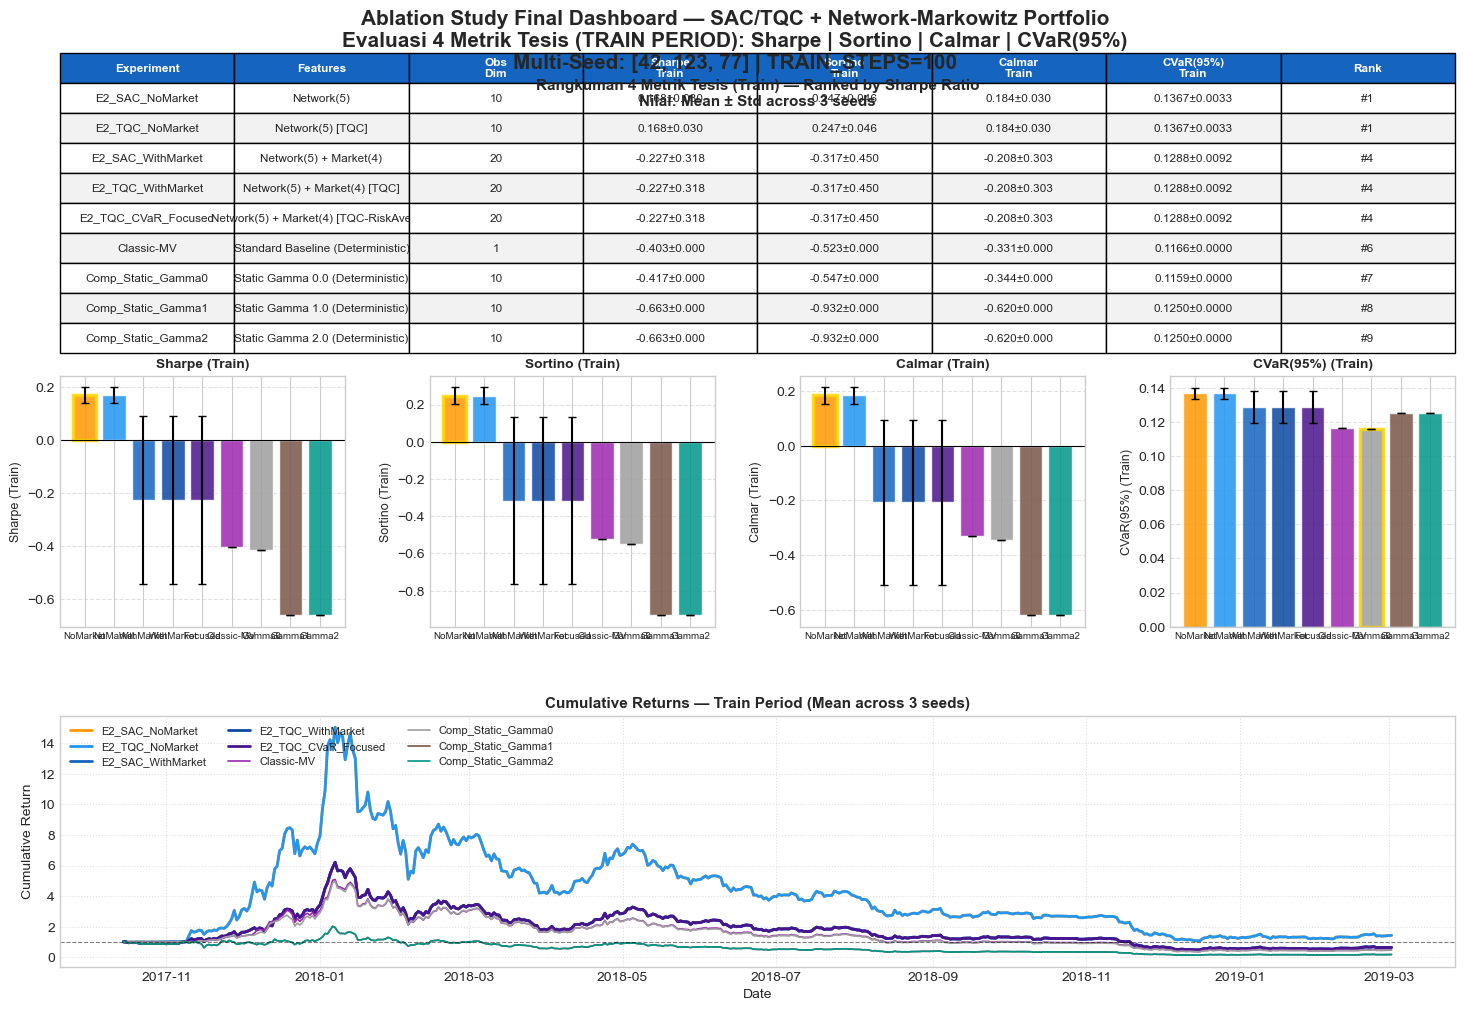

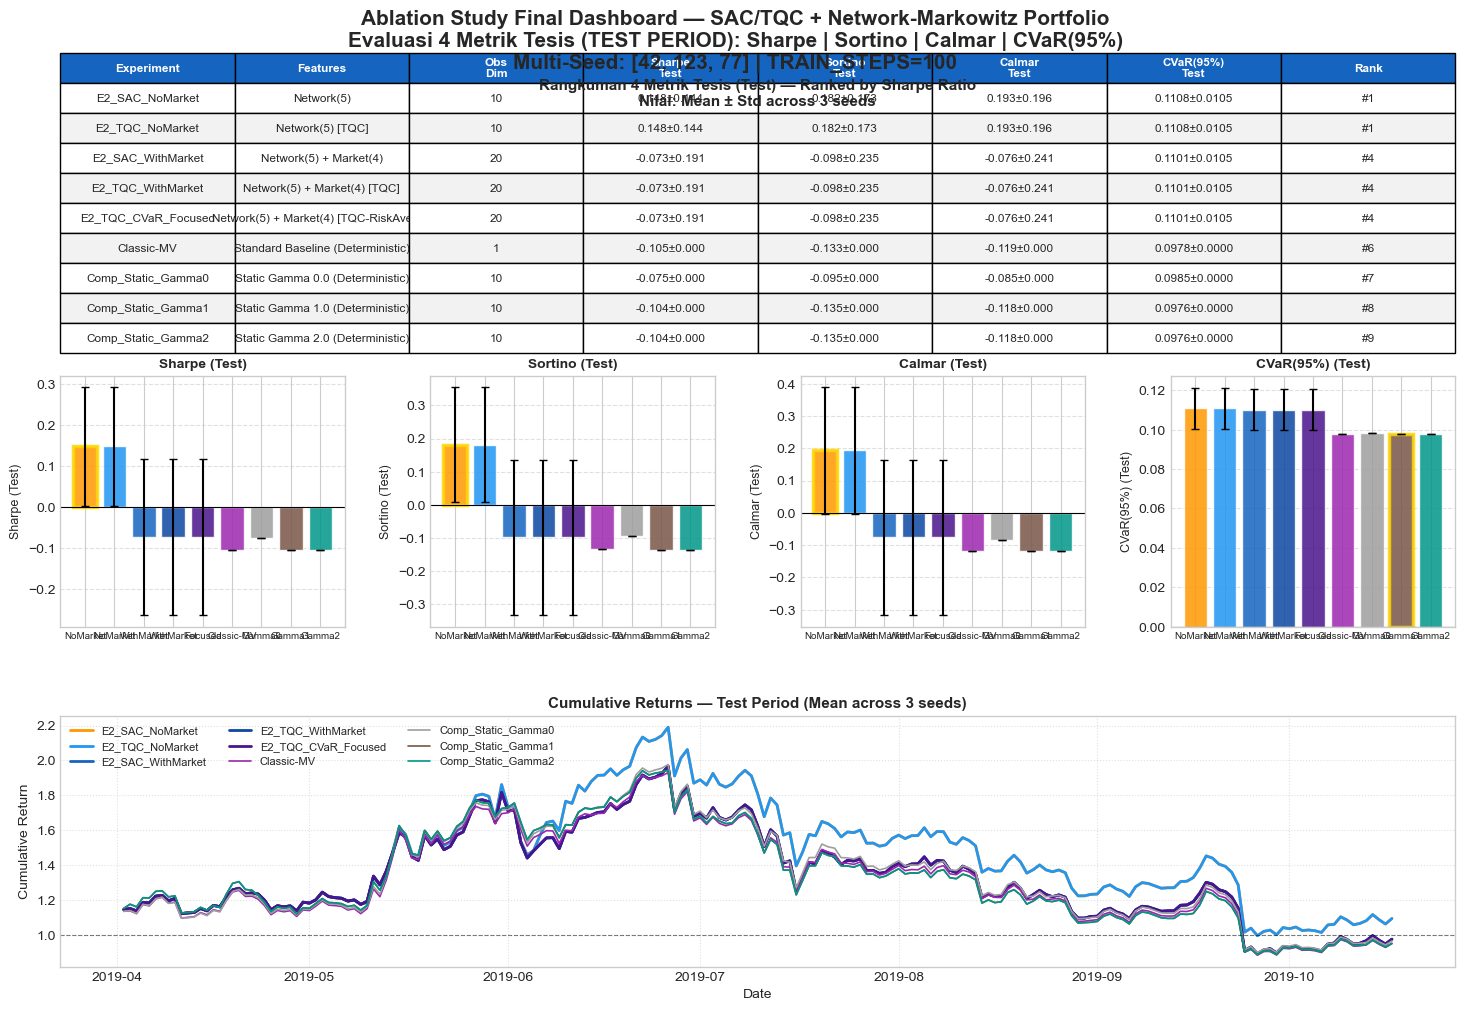


✅ Final Dashboard Selesai! Cek file:
  - tqc_results/final_dashboard_train.png
  - tqc_results/final_dashboard_test.png


In [96]:

DASHBOARD_COLORS = {
    'Comp_Static_Gamma0' : '#9E9E9E', # Grey
    'Comp_Static_Gamma1' : '#795548', # Brown
    'Comp_Static_Gamma2' : '#009688', # Teal
    'Classic-MV'         : '#9C27B0', # Purple
    'E2_SAC_NoMarket'    : '#FF9800', # Orange
    'E2_SAC_WithMarket'  : '#1565C0', # Blue
    'E2_TQC_NoMarket'    : '#2196F3', # Light Blue
    'E2_TQC_WithMarket'  : '#0D47A1', # Dark Blue
    'E2_TQC_CVaR_Focused': '#4A148C', # Dark Purple
}

def plot_final_dashboard(ablation_results, summary_df, period='Train'):
    """
    Menghasilkan dashboard komprehensif seperti yang diminta.
    """
    p_lower = period.lower()
    fig = plt.figure(figsize=(18, 11))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[0.8, 1.2, 1.2], hspace=0.4)

    # ── Header ──
    header_text = (
        f"Ablation Study Final Dashboard — SAC/TQC + Network-Markowitz Portfolio\n"
        f"Evaluasi 4 Metrik Tesis ({period.upper()} PERIOD): Sharpe | Sortino | Calmar | CVaR(95%)\n"
        f"Multi-Seed: {SEEDS} | TRAIN_STEPS={TRAIN_STEPS}"
    )
    plt.suptitle(header_text, fontsize=15, fontweight='bold', y=0.98)

    # ── 1. Table Summary (Top) ──
    ax_table = fig.add_subplot(gs[0])
    ax_table.axis('off')
    ax_table.set_title(f"Rangkuman 4 Metrik Tesis ({period}) — Ranked by Sharpe Ratio\nNilai: Mean ± Std across {len(SEEDS)} seeds",
                       fontsize=11, fontweight='bold', pad=10)

    # Prepare data for table
    table_data = []
    cols_to_show = ['Features', 'Obs Dim', f'SharpeRatio_{period}_Mean', f'SortinoRatio_{period}_Mean',
                    f'CalmarRatio_{period}_Mean', f'CVaR95pct_{period}_Mean', 'Rank']

    # Rename columns for display
    display_cols = ['Experiment', 'Features', 'Obs\nDim', 'Sharpe\n' + period, 'Sortino\n' + period,
                    'Calmar\n' + period, 'CVaR(95%)\n' + period, 'Rank']

    for idx, row in summary_df.iterrows():
        r = [idx]
        r.append(row['Features'])
        r.append(int(row['Obs Dim']))
        # Add metrics as Mean ± Std
        for m in ['SharpeRatio', 'SortinoRatio', 'CalmarRatio']:
            mean = row[f'{m}_{period}_Mean']
            std  = row[f'{m}_{period}_Std']
            r.append(f"{mean:.3f}±{std:.3f}")
        # CVaR
        r.append(f"{row[f'CVaR95pct_{period}_Mean']:.4f}±{row[f'CVaR95pct_{period}_Std']:.4f}")
        r.append(f"#{int(row['Rank'])}")
        table_data.append(r)

    table = ax_table.table(cellText=table_data, colLabels=display_cols, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1.0, 1.8)

    # Styling Table Header
    for (row_idx, col_idx), cell in table.get_celld().items():
        if row_idx == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#1565C0') # Blue header
        else:
            if row_idx % 2 == 0:
                cell.set_facecolor('#f2f2f2')

    # ── 2. Bar Charts (Middle) ──
    inner_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[1], wspace=0.3)
    metrics_to_plot = [
        (f'SharpeRatio_{period}_Mean',  f'SharpeRatio_{period}_Std',  f'Sharpe ({period})',  False),
        (f'SortinoRatio_{period}_Mean', f'SortinoRatio_{period}_Std', f'Sortino ({period})', False),
        (f'CalmarRatio_{period}_Mean',  f'CalmarRatio_{period}_Std',  f'Calmar ({period})',  False),
        (f'CVaR95pct_{period}_Mean',    f'CVaR95pct_{period}_Std',    f'CVaR(95%) ({period})', True),
    ]

    exp_list = list(summary_df.index)
    colors   = [DASHBOARD_COLORS.get(e, '#888888') for e in exp_list]

    for i, (mean_col, std_col, label, lower_better) in enumerate(metrics_to_plot):
        ax = fig.add_subplot(inner_gs[i])
        vals = summary_df[mean_col].values
        errs = summary_df[std_col].values

        bars = ax.bar(range(len(exp_list)), vals, yerr=errs, color=colors,
                      edgecolor='white', capsize=3, alpha=0.85)

        # Highlight best
        best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(2.5)

        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.set_ylabel(label, fontsize=9)
        ax.set_xticks(range(len(exp_list)))
        # Shorten labels for bar chart
        ax.set_xticklabels([e.split('_')[-1] if '_' in e else e for e in exp_list], fontsize=7, rotation=0)
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)

    # ── 3. Cumulative Returns (Bottom) ──
    ax_line = fig.add_subplot(gs[2])
    ax_line.set_title(f"Cumulative Returns — {period} Period (Mean across {len(SEEDS)} seeds)",
                      fontsize=11, fontweight='bold')

    for exp_id in exp_list:
        mean_ret = pd.concat([ablation_results[exp_id][p_lower][s] for s in SEEDS], axis=1).mean(axis=1)
        cum = (1 + mean_ret).cumprod()
        ax_line.plot(cum, label=exp_id, color=DASHBOARD_COLORS.get(exp_id, '#888'),
                     linewidth=2.0 if 'SAC' in exp_id or 'TQC' in exp_id else 1.2)

    ax_line.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax_line.set_ylabel('Cumulative Return', fontsize=10)
    ax_line.set_xlabel('Date', fontsize=10)
    ax_line.legend(fontsize=8, ncol=3, loc='upper left')
    ax_line.grid(True, linestyle=':', alpha=0.6)

    plt.savefig(f'tqc_results/final_dashboard_{p_lower}.png', dpi=200, bbox_inches='tight')
    plt.show()

# Generate the dashboard for Training period (as in the image)
plot_final_dashboard(ablation_results, summary_df, period='Train')

# Also generate for Testing period as a bonus
plot_final_dashboard(ablation_results, summary_df, period='Test')

print("\n✅ Final Dashboard Selesai! Cek file:")
print(f"  - tqc_results/final_dashboard_train.png")
print(f"  - tqc_results/final_dashboard_test.png")
